In [2]:
import os

dataset_path = "/Users/hassankhalid/Downloads/PCB_DATASET/PCB_PROJECT/images"

classes = os.listdir(dataset_path)

print("Classes Found:")
print(classes)

print("\nNumber of Classes:", len(classes))

Classes Found:
['Mouse_bite', '.DS_Store', 'Spur', 'Short', 'Spurious_copper', 'Open_circuit', 'Missing_hole']

Number of Classes: 7


In [3]:
classes = [
    cls for cls in os.listdir(dataset_path)
    if not cls.startswith('.')
]

print("Classes Found:")
print(classes)

print("\nNumber of Classes:", len(classes))

Classes Found:
['Mouse_bite', 'Spur', 'Short', 'Spurious_copper', 'Open_circuit', 'Missing_hole']

Number of Classes: 6


In [4]:
for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    images = [
        img for img in os.listdir(class_path)
        if not img.startswith('.')
    ]

    print(f"{cls}: {len(images)} images")

Mouse_bite: 115 images
Spur: 115 images
Short: 116 images
Spurious_copper: 116 images
Open_circuit: 116 images
Missing_hole: 115 images


In [5]:
from PIL import Image
import os

sample_class = classes[0]

sample_image = [
    img for img in os.listdir(os.path.join(dataset_path, sample_class))
    if not img.startswith('.')
][0]

img_path = os.path.join(
    dataset_path,
    sample_class,
    sample_image
)

img = Image.open(img_path)

print("Class:", sample_class)
print("Image Size:", img.size)
print("Image Mode:", img.mode)

Class: Mouse_bite
Image Size: (3034, 1586)
Image Mode: RGB


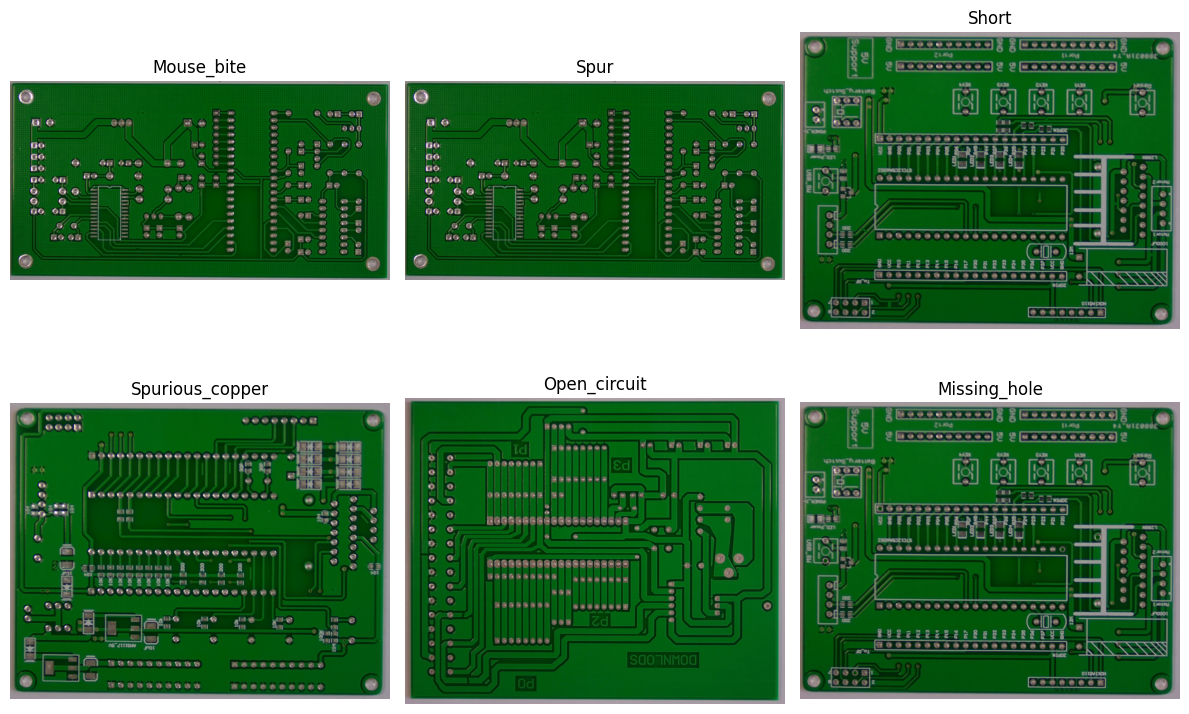

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
import os

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, cls in zip(axes.flatten(), classes):

    img_name = [
        img for img in os.listdir(os.path.join(dataset_path, cls))
        if not img.startswith('.')
    ][0]

    img_path = os.path.join(dataset_path, cls, img_name)

    img = Image.open(img_path)

    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd

summary = []

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    count = len([
        img for img in os.listdir(folder)
        if not img.startswith('.')
    ])

    summary.append([cls, count])

df = pd.DataFrame(
    summary,
    columns=["Class", "Images"]
)

print(df)

             Class  Images
0       Mouse_bite     115
1             Spur     115
2            Short     116
3  Spurious_copper     116
4     Open_circuit     116
5     Missing_hole     115


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

/Users/hassankhalid/tf_env/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [9]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 555 images belonging to 6 classes.
Found 138 images belonging to 6 classes.


In [10]:
print(train_generator.class_indices)

{'Missing_hole': 0, 'Mouse_bite': 1, 'Open_circuit': 2, 'Short': 3, 'Spur': 4, 'Spurious_copper': 5}


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization
)

model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),

    Dense(128,activation='relu'),

    Dropout(0.5),

    Dense(6,activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,430 (435.27 KB)

 Trainable params: 110,982 (433.52 KB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [27]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[early_stop]
)

Epoch 1/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.1964 - loss: 2.0044 - val_accuracy: 0.1667 - val_loss: 1.7979
Epoch 2/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1532 - loss: 1.9987 - val_accuracy: 0.1667 - val_loss: 1.8187
Epoch 3/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.1802 - loss: 1.9121 - val_accuracy: 0.1667 - val_loss: 1.8202
Epoch 4/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.1712 - loss: 1.9533 - val_accuracy: 0.1667 - val_loss: 1.8185
Epoch 5/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.1550 - loss: 1.9542 - val_accuracy: 0.1667 - val_loss: 1.8308
Epoch 6/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.1730 - loss: 1.9193 - val_accuracy: 0.1667 - val_loss: 1.8297
Epoch 7/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1405 - loss: 1.9706 - val_accuracy: 0.1667 - val_loss: 1.8251
Epoch 8/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1712 - loss: 1.9334 - val_accuracy: 0.1667 - val_loss:

In [21]:
print(train_generator.class_indices)
print(train_generator.num_classes)

{'Missing_hole': 0, 'Mouse_bite': 1, 'Open_circuit': 2, 'Short': 3, 'Spur': 4, 'Spurious_copper': 5}
6


In [22]:
x_batch, y_batch = next(train_generator)

print(x_batch.shape)
print(y_batch.shape)

print(y_batch[0])

(32, 224, 224, 3)
(32, 6)
[0. 0. 0. 1. 0. 0.]


In [23]:
print(train_generator.samples)
print(val_generator.samples)

555
138


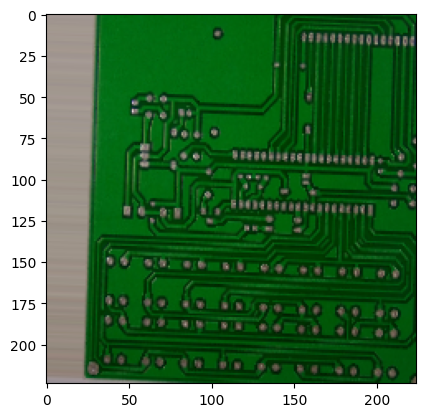

[0. 0. 1. 0. 0. 0.]


In [24]:
import matplotlib.pyplot as plt

x_batch, y_batch = next(train_generator)

plt.imshow(x_batch[0])
plt.show()

print(y_batch[0])

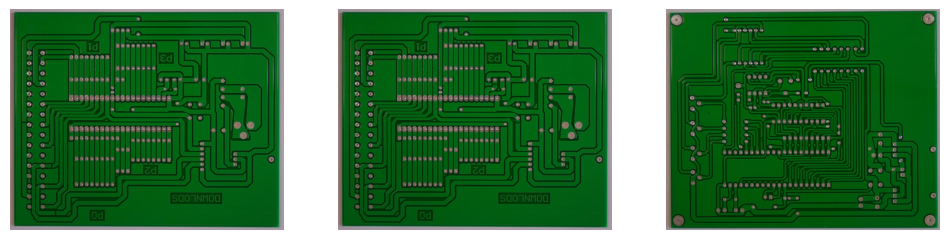

In [28]:
import matplotlib.pyplot as plt
from PIL import Image
import os

class_name = "Open_circuit"

folder = os.path.join(dataset_path, class_name)

files = [f for f in os.listdir(folder) if not f.startswith('.')]

fig, axes = plt.subplots(1,3, figsize=(12,4))

for i in range(3):
    img = Image.open(os.path.join(folder, files[i]))
    axes[i].imshow(img)
    axes[i].axis("off")

plt.show()

In [29]:
print(model.optimizer.learning_rate.numpy())


0.001


In [30]:
model.save("baseline_cnn_pcb.keras")

In [48]:
print(val_generator.shuffle)

import numpy as np
val_generator.reset()
y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes

False
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 615ms/step


In [43]:
from sklearn.metrics import classification_report

class_names = list(val_generator.class_indices.keys())

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))

                 precision    recall  f1-score   support

   Missing_hole       0.00      0.00      0.00        23
     Mouse_bite       0.17      1.00      0.29        23
   Open_circuit       0.00      0.00      0.00        23
          Short       0.00      0.00      0.00        23
           Spur       0.00      0.00      0.00        23
Spurious_copper       0.00      0.00      0.00        23

       accuracy                           0.17       138
      macro avg       0.03      0.17      0.05       138
   weighted avg       0.03      0.17      0.05       138



/Users/hassankhalid/tf_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hassankhalid/tf_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hassankhalid/tf_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [42]:
import numpy as np

val_generator.reset()

y_pred = model.predict(val_generator)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_generator.classes

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 616ms/step


In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

print(cm)

[[ 0 23  0  0  0  0]
 [ 0 23  0  0  0  0]
 [ 0 23  0  0  0  0]
 [ 0 23  0  0  0  0]
 [ 0 23  0  0  0  0]
 [ 0 23  0  0  0  0]]


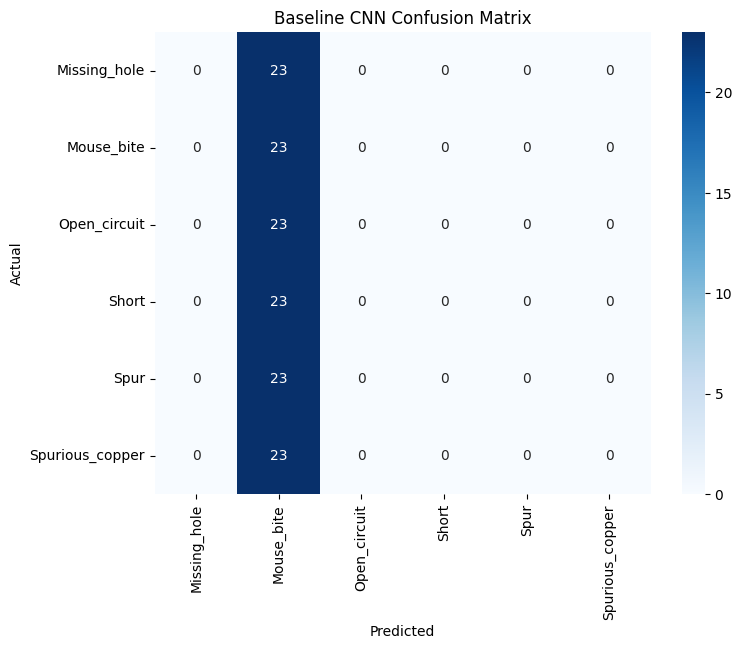

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline CNN Confusion Matrix")

plt.show()

In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_true, y_pred_classes)

precision = precision_score(
    y_true,
    y_pred_classes,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred_classes,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred_classes,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.16666666666666666
Precision: 0.027777777777777776
Recall   : 0.16666666666666666
F1 Score : 0.047619047619047616


/Users/hassankhalid/tf_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Observations from Baseline CNN Training

The baseline CNN model was trained using three convolutional layers followed by Batch Normalization, Global Average Pooling, and fully connected layers. Despite multiple training epochs and the use of data augmentation, the model achieved approximately 16–20% training accuracy and 16.67% validation accuracy.
Since the dataset contains six defect classes, a validation accuracy of 16.67% is equivalent to random guessing. This indicates that the model was unable to learn meaningful defect-related features from the training data.

### Possible Reasons

1. Limited Dataset Size
The dataset contains only 693 images distributed across six defect categories. Training a CNN from scratch on such a small dataset can be challenging because the model has very limited examples from which to learn representative features.

2. Very Small Defect Regions
PCB defects occupy only a small portion of the overall image. During preprocessing, the original high-resolution images were resized to 224×224 pixels. As a result, important defect details may have become less distinguishable, making feature extraction difficult.

3. Variation in PCB Layouts
Images belonging to the same defect category contain different PCB designs and layouts. The model must therefore learn to recognize defect patterns while simultaneously handling large variations in board structure, which increases the complexity of the classification task.

4. Training From Random Initialization
Unlike pretrained networks, the baseline CNN starts with randomly initialized weights. With limited training data, the model may not be able to learn robust low-level and high-level visual features required for accurate defect classification.

### Conclusion
The baseline CNN was unable to achieve satisfactory performance on the PCB defect dataset and performed close to random guessing. This experiment suggests that training a CNN from scratch may not be suitable for this dataset. Therefore, transfer learning approaches using pretrained architectures will be explored in subsequent experiments.

In [11]:
print(val_generator.shuffle)

False


In [25]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

In [32]:
print(train_generator.image_shape)

(224, 224, 3)


In [33]:
print(train_generator.class_indices)

{'Missing_hole': 0, 'Mouse_bite': 1, 'Open_circuit': 2, 'Short': 3, 'Spur': 4, 'Spurious_copper': 5}


In [34]:
batch_x, batch_y = next(train_generator)

print(batch_x.min())
print(batch_x.max())
print(batch_x.mean())

0.0
0.99202716
0.21183212


In [35]:
print(train_generator.class_mode)
print(val_generator.class_mode)

categorical
categorical


In [36]:
batch_x, batch_y = next(train_generator)

print(batch_y.shape)
print(batch_y[0])

(32, 6)
[0. 0. 1. 0. 0. 0.]


In [38]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen2 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,

    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

In [39]:
val_datagen2 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

In [40]:
train_generator2 = train_datagen2.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator2 = val_datagen2.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 555 images belonging to 6 classes.
Found 138 images belonging to 6 classes.


In [42]:
batch_x, batch_y = next(train_generator2)

print(batch_x.min())
print(batch_x.max())
print(batch_x.mean())

-1.0
0.99479413
-0.57040066


In [43]:
import os
import certifi

os.environ['SSL_CERT_FILE'] = certifi.where()

from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [46]:
model2 = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')

])

In [47]:
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [48]:
history = model2.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.1766 - loss: 3.5067 - val_accuracy: 0.1667 - val_loss: 2.1701
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1676 - loss: 4.3905 - val_accuracy: 0.1522 - val_loss: 1.9255
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1892 - loss: 4.4071 - val_accuracy: 0.1667 - val_loss: 1.8766
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.1640 - loss: 4.6512 - val_accuracy: 0.1667 - val_loss: 1.9227
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1333 - loss: 4.5577 - val_accuracy: 0.1812 - val_loss: 1.8674
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1586 - loss: 4.5534 - val_accuracy: 0.1667 - val_loss: 1.8567
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1712 - loss: 4.1502 - val_accuracy: 0.1667 - val_loss: 1.9050
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1784 - loss: 4.1257 - val_accuracy: 0.1667 - val_loss:

In [49]:
from sklearn.metrics import classification_report
import numpy as np

val_generator2.reset()

y_pred = model.predict(val_generator2)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_generator2.classes

class_names = list(val_generator2.class_indices.keys())

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))

5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 962ms/step
                 precision    recall  f1-score   support

   Missing_hole       0.00      0.00      0.00        23
     Mouse_bite       0.00      0.00      0.00        23
   Open_circuit       0.00      0.00      0.00        23
          Short       0.00      0.00      0.00        23
           Spur       0.00      0.00      0.00        23
Spurious_copper       0.17      1.00      0.29        23

       accuracy                           0.17       138
      macro avg       0.03      0.17      0.05       138
   weighted avg       0.03      0.17      0.05       138



/Users/hassankhalid/tf_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hassankhalid/tf_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hassankhalid/tf_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

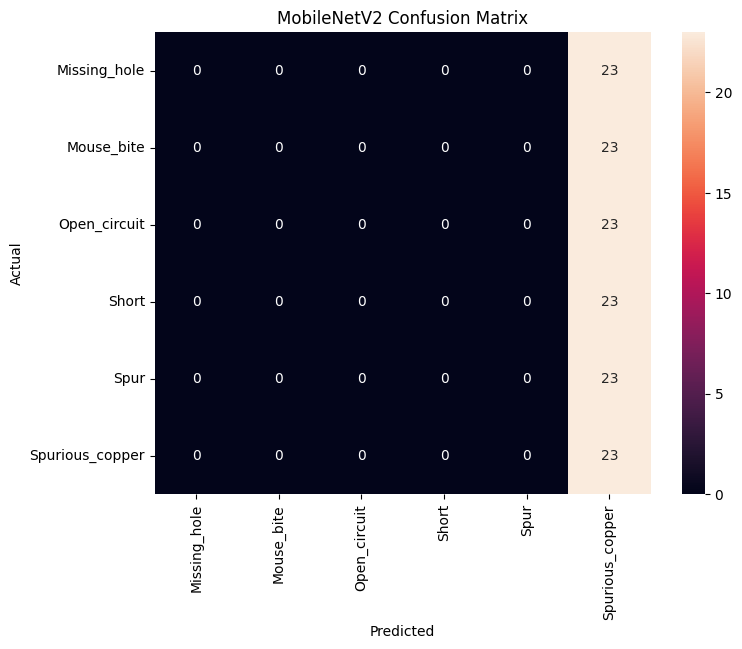

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV2 Confusion Matrix")
plt.show()

In [51]:
loss, accuracy = model.evaluate(val_generator2)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 645ms/step - accuracy: 0.1667 - loss: 2.1057
Validation Loss: 2.105691909790039
Validation Accuracy: 0.1666666716337204


## MobileNetV2 Performance Analysis

A transfer learning approach using MobileNetV2 pre-trained on ImageNet was implemented to improve classification performance over the baseline CNN model.

The MobileNetV2 feature extractor was frozen and only the custom classification head was trained on the PCB defect dataset. Data augmentation techniques such as rotation, translation, and zooming were applied during training. Additionally, MobileNetV2-specific preprocessing was used to ensure compatibility with the pre-trained network.

Despite the use of transfer learning, the model achieved a validation accuracy close to random guessing (~16.7%). The classification report revealed that the model predominantly predicted a single class (Spurious_copper) while failing to correctly classify the remaining defect categories.

### Possible Reasons for Poor Performance

1. Tiny Defect Regions
   - PCB defects occupy only a very small portion of the original image.
   - Important visual information may be lost when resizing images from approximately 3034×1586 pixels to 224×224 pixels.

2. Global Image Classification Limitation
   - The model attempts to classify the entire PCB image rather than focusing on the defect region.
   - Defect patterns become difficult to distinguish after resizing.

3. Limited Dataset Size
   - The dataset contains only about 115 images per class.
   - Such a small dataset may be insufficient for learning subtle defect variations.

4. Dataset Characteristics
   - Many PCB defect datasets are more suitable for localization or detection tasks rather than whole-image classification.

### Conclusion

Transfer learning with MobileNetV2 did not provide a significant improvement over the baseline CNN. The results suggest that the primary challenge lies in the dataset representation and defect visibility rather than the model architecture itself.

Future work could involve defect localization, region-based cropping, object detection approaches, or training on higher-resolution image patches.